# Task 5: Decision Trees and Random Forests

## Objective
The objective of this task is to learn and implement tree-based machine learning models for classification.

In this project, I use the Heart Disease dataset to:
- Train and visualize a Decision Tree Classifier.
- Analyze overfitting by controlling tree depth.
- Train a Random Forest Classifier.
- Compare the performance of both models.
- Analyze feature importance.
- Evaluate the models using cross-validation.

## Importing Required Libraries

The following libraries are used for data analysis, visualization, machine learning, and model evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("heart.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


### Dataset Information

We check the dataset size and column details.

In [3]:
print(df.shape)
df.info()


(1025, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


### Check Missing Values

We check if the dataset contains any missing values.

In [4]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


### Target Variable Distribution

We check how the target values are distributed in the dataset.

target
1    526
0    499
Name: count, dtype: int64


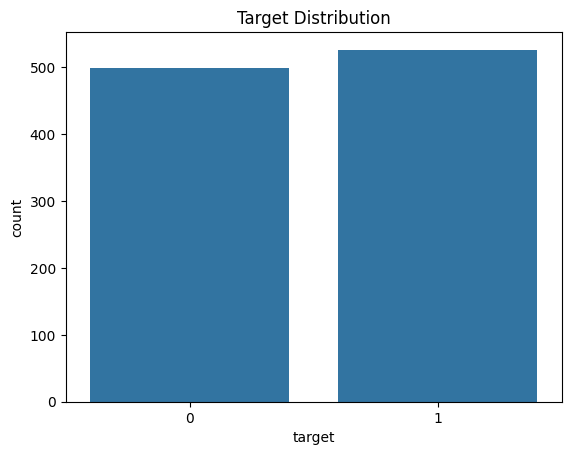

In [5]:
print(df["target"].value_counts())

sns.countplot(x="target", data=df)
plt.title("Target Distribution")
plt.show()


### Define Features and Target

We separate the input features and the target variable.

In [6]:
X = df.drop("target", axis=1)
y = df["target"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (1025, 13)
Target: (1025,)


### Split the Dataset

We split the data into training and testing sets.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

### Train the Decision Tree

We train a Decision Tree model using the training data.

In [8]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)
print("Decision Tree trained successfully!")


Decision Tree trained successfully!


### Make Predictions

We use the trained Decision Tree to predict the test data.

In [9]:
dt_pred = dt.predict(X_test)

print("Predictions:")
print(dt_pred[:10])

Predictions:
[1 1 0 1 0 1 0 0 1 0]


### Evaluate the Decision Tree

We check the accuracy of the Decision Tree model.

In [10]:
dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:")
print(dt_accuracy)

Decision Tree Accuracy:
0.9853658536585366


### Classification Report

We check precision, recall, and F1-score to evaluate the model.

In [12]:
print(classification_report(
    y_test,
    dt_pred
))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



### Visualize the Decision Tree

We visualize the Decision Tree to understand how it makes decisions.

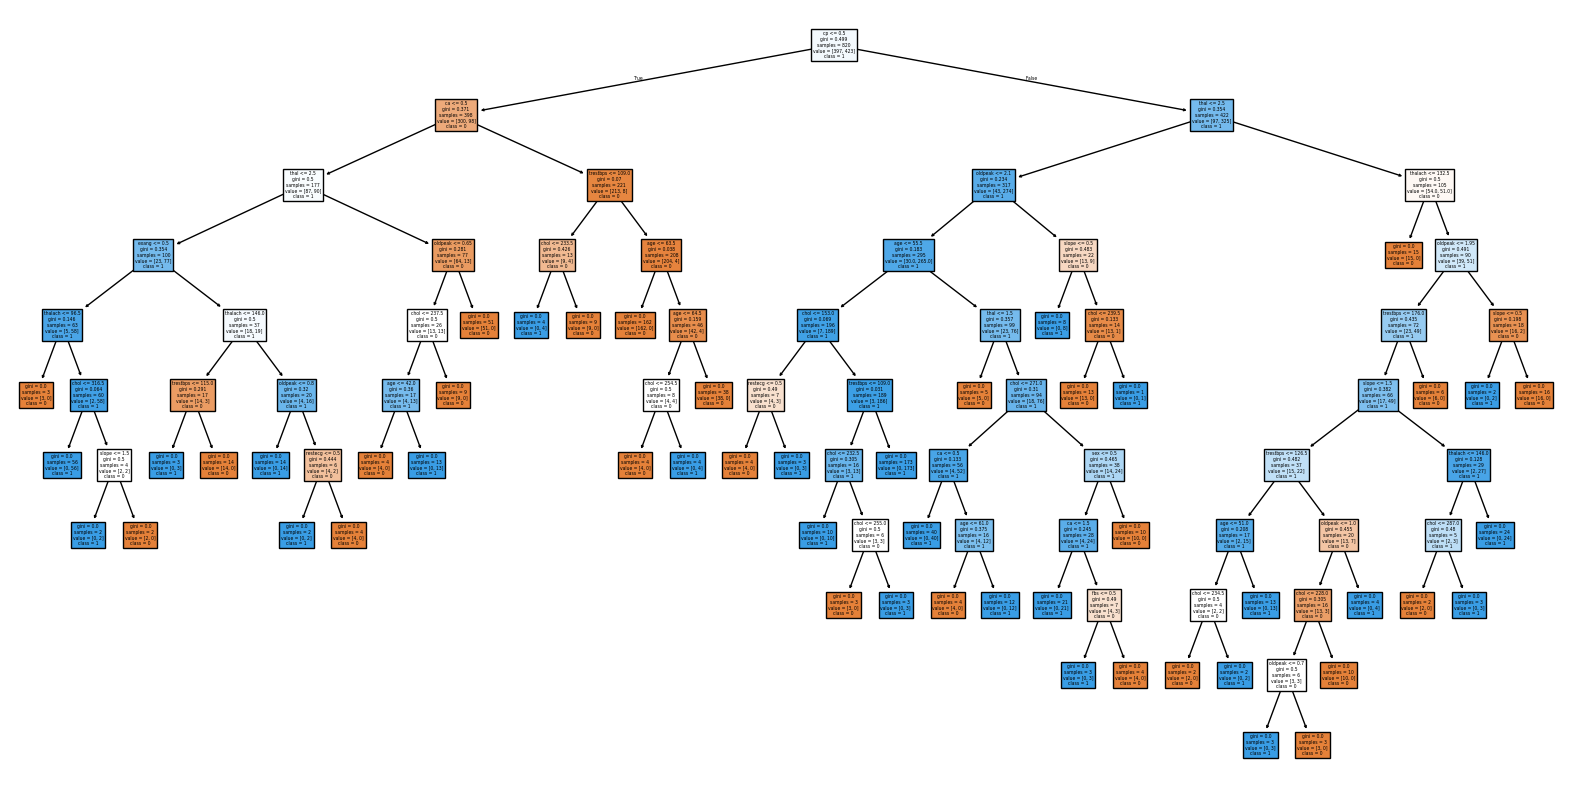

In [13]:
plt.figure(figsize=(20, 10))

plot_tree(dt, feature_names=X.columns,
          class_names=["0", "1"], filled=True)

plt.show()

### Analyze Overfitting

We test different tree depths to see how model performance changes.

In [14]:
depths = range(1, 11)
train_scores = []
test_scores = []

for depth in depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    train_scores.append(model.score(X_train, y_train))
    test_scores.append(model.score(X_test, y_test))

### Visualize Overfitting

We compare training and testing accuracy at different tree depths.

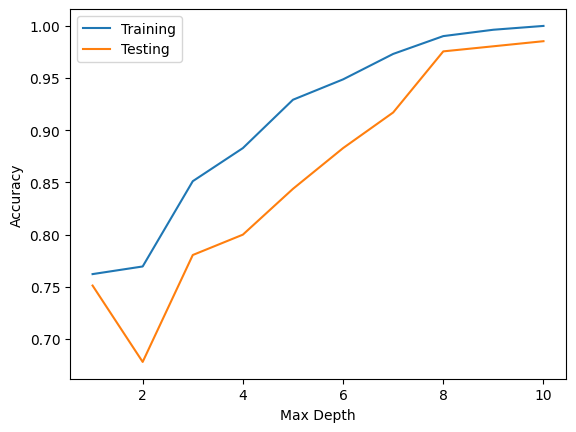

In [15]:
plt.plot(depths, train_scores, label="Training")
plt.plot(depths, test_scores, label="Testing")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

### Train Random Forest

We train a Random Forest model using multiple Decision Trees.

In [16]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

### Random Forest Predictions

We use the trained Random Forest model to predict the test data.

In [17]:
rf_pred = rf.predict(X_test)

print("Predictions:")
print(rf_pred[:10])

Predictions:
[1 1 0 1 0 1 0 0 1 0]


### Evaluate Random Forest

We check the accuracy of the Random Forest model.

In [18]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:")
print(rf_accuracy)

Random Forest Accuracy:
0.9853658536585366


### Compare Model Accuracy

We compare the accuracy of the Decision Tree and Random Forest models.

In [19]:
comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [dt_accuracy, rf_accuracy]
})

comparison

,Model,Accuracy
0,Decision Tree,0.985366
1,Random Forest,0.985366


### Visualize Model Comparison

We use a graph to compare the accuracy of both models.

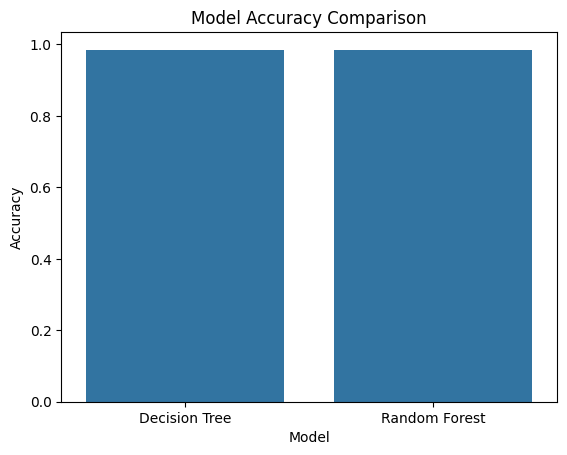

In [20]:
sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.show()

### Feature Importance

Feature importance shows which features have the greatest influence on the Random Forest predictions.

In [21]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance.sort_values(by="Importance", ascending=False)

,Feature,Importance
2,cp,0.135072
11,ca,0.127327
7,thalach,0.122169
9,oldpeak,0.121905
12,thal,0.110518
0,age,0.077908
4,chol,0.074822
3,trestbps,0.071171
8,exang,0.057594
10,slope,0.045782


### Visualize Feature Importance

We use a graph to see which features are most important.

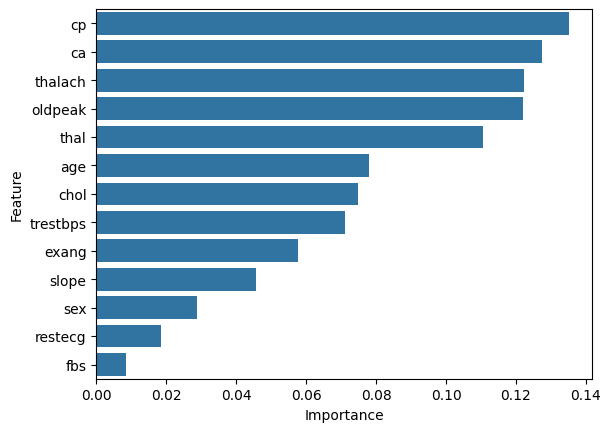

In [22]:
importance = importance.sort_values(
    by="Importance",
    ascending=False
)

sns.barplot(data=importance, x="Importance", y="Feature")
plt.show()

### Cross-Validation

We use cross-validation to check the overall performance of both models.

In [23]:
dt_cv = cross_val_score(dt, X, y, cv=5)
rf_cv = cross_val_score(rf, X, y, cv=5)

print("Decision Tree CV:", dt_cv.mean())
print("Random Forest CV:", rf_cv.mean())

Decision Tree CV: 1.0
Random Forest CV: 0.9970731707317073


### Cross-Validation Comparison

We compare the average cross-validation accuracy of both models.

In [24]:
cv_comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "CV Accuracy": [dt_cv.mean(), rf_cv.mean()]
})

cv_comparison

,Model,CV Accuracy
0,Decision Tree,1.000000
1,Random Forest,0.997073


### Conclusion

The Decision Tree was easy to understand and visualize, while the Random Forest generally provided better and more stable performance. Cross-validation was used to evaluate both models.

In [25]:
print("Decision Tree Accuracy:", dt_accuracy)
print("Random Forest Accuracy:", rf_accuracy)
print("Decision Tree CV:", dt_cv.mean())
print("Random Forest CV:", rf_cv.mean())

Decision Tree Accuracy: 0.9853658536585366
Random Forest Accuracy: 0.9853658536585366
Decision Tree CV: 1.0
Random Forest CV: 0.9970731707317073
